# Point-Wise Missing Patterns
We will now look at the imputation problem for point-wise missing values in more detail. In particular, we will revisig how to format the data for the $\texttt{FIM-}\ell$ model and extract the estimated velocity. 

In [1]:
import warnings
warnings.filterwarnings("ignore")
from transformers.utils import logging
logging.disable_progress_bar()
from datasets.utils.logging import disable_progress_bar 
disable_progress_bar()

%matplotlib inline

import torch
from datasets import load_dataset
from imputation_tutorial_helper import plot_trajectories

from fim.models.imputation_pointwise import FIMImpPointBase, FIMImpPoint, StaticWindowing, ImputationConcepts

## Estimating the Velocity of a Van der Pol Oscillator

We start by loading a discrete approximations of an Van der Pol oscillator
```{math}
\begin{align}
dx &= v\\
dv &= \mu(1-x^2)v-x
\end{align}
```
for 12 different initial conditions and $\mu=0.1$:

In [2]:
data = load_dataset(
    "FIM4Science/van-der-pol-example", download_mode="force_redownload", name="default"
    )["train"]  # 12 paths
data.set_format("torch")

We corrupt the data with noise and randomly drop a percentage of observations, which we will impute. Note that we indicate these points by a mask, where `True` corresponds to dropped points. 

In [3]:
B = 12
T = 128
D = 1

noise = 0.05
missing_percentage = 0.1

obs_times = data["t"][: B * T].reshape(B, T)

obs_values_clean = data["x"][: B * T].reshape(B, T)
multiplicative_error = 1 + torch.normal(0, noise, size=obs_values_clean.shape)
obs_values_noisy = obs_values_clean * multiplicative_error

obs_mask = torch.bernoulli(torch.ones_like(obs_times) * missing_percentage).type(torch.bool)

In this example, we evaluate the interpolating function on a much finer grid than the observations. 

In [4]:
G = 512

min_t = torch.amin(obs_times, dim=1, keepdim=True) - 0.1 
max_t = torch.amax(obs_times, dim=1, keepdim=True) + 0.1

evaluation_times = min_t + torch.linspace(0, 1, G).view(1, G) * (max_t - min_t)
evaluation_times = torch.sort(evaluation_times, dim=1)[0] # [B, G]

As in the [previous tutorial page](imputation.ipynb), we load a pre-trained `FIMImpPointBase` model, define a windowing scheme, and instantiate `FIMImpPoint`, which provides a good interface for this interpolation task.

In [5]:
fim_imp_pointwise_base = FIMImpPointBase.from_pretrained("FIM4Science/fim-imp-pointwise-base")

windowing = StaticWindowing(windows_count=4, overlap_percentage=0.3)

fim_imp_pointwise = FIMImpPoint(
    fim_imp_pointwise_base=fim_imp_pointwise_base, windowing=windowing)

You are using a model of type fimode to instantiate a model of type FIMImpPointBase. This is not supported for all configurations of models and can yield errors.


After reshaping the inputs into the shapes `FIMImpPoint` expects, we apply the model. 

In [6]:
obs_times = obs_times.view(B, T, 1)
obs_values_noisy = obs_values_noisy.view(B, T, D)
obs_mask = obs_mask.view(B, T, 1)
evaluation_times = evaluation_times.view(B, G, 1)

with torch.no_grad():
    output = fim_imp_pointwise.forward(
        obs_times, obs_values_noisy, evaluation_times, obs_mask
    )
    assert isinstance(output, ImputationConcepts)

`ImputationConcepts` is a dataclass containing the relevant outputs. 

For this tutorial, the reconstructed values at the `evaluation_times` and the estimated velocity are of interest. 

In [7]:
print(f"Evaluation times shape: {output.evaluation_times.shape}") # [B, G, 1], same as evaluation_times
print(f"Reconstructed values shape: {output.reconstructed_values.shape}") # [B, G, D]
print(f"Estimated velocity shape: {output.vector_field_mean.shape}") # [B, G, D]

Evaluation times shape: torch.Size([12, 512, 1])
Reconstructed values shape: torch.Size([12, 512, 1])
Estimated velocity shape: torch.Size([12, 512, 1])


Finally, we visualize the data and the model estimates. 

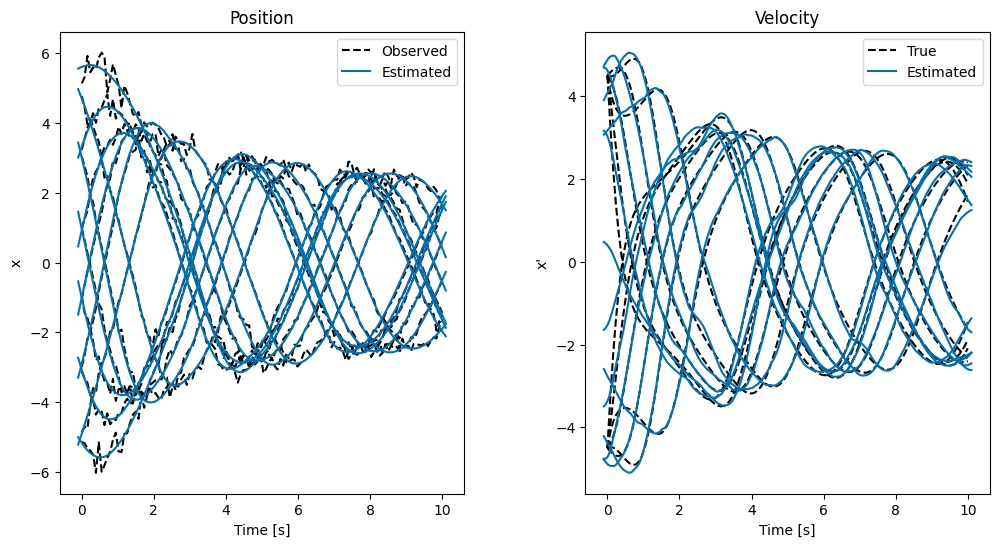

In [8]:
import matplotlib.pyplot as plt

true_velocity = data["v"][: B * T].view(B, T, 1)

plot_trajectories(
    eval_times = output.evaluation_times,
    obs_times=obs_times,
    pred_x=output.reconstructed_values, 
    obs_x=obs_values_noisy,
    pred_v=output.vector_field_mean, 
    obs_v=true_velocity
)

We can also recreate some of the plots from the paper displaying the phase portraits of both Van der Pol systems and our predicted ODE approximations:

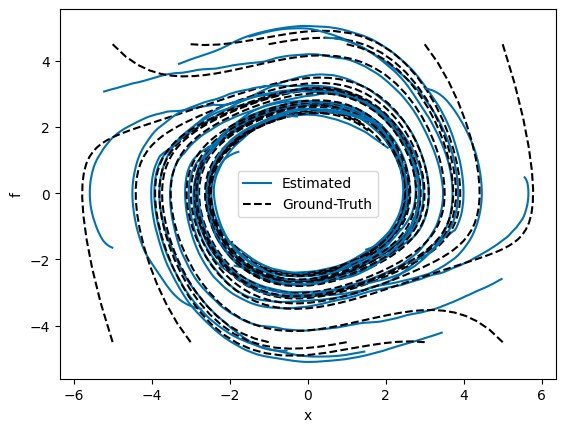

In [9]:
for i in range(12):
    plt.plot(
        output.reconstructed_values[i], 
        output.vector_field_mean[i], 
        c="#0072B2", label="Estimated" if i == 0 else None)
    plt.plot(
        obs_values_clean[i].flatten(), 
        true_velocity[i].flatten(), 
        c="black", linestyle="dashed", label="Ground-Truth" if i == 0 else None)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("f")

## Estimating the Velocity of a Rössler Attractor

Next we load a discretization of the more complicated Rössler attractor, which was discretized at a much higher temporal resolution, hinting that we also need to increase the number of windows
used to estimate the underlying ODE. We therefore, in accordance with the paper, analyze the data using 32 windows instead of the previous 4 even though the total time for which the systems were simulated is the same! The corresponding ODE is given by 
```{math}
\begin{align}
dx &= -5(y+z)\\
dy &= (0.2y+x)\\
dz &= 5(0.2+z (-5.7+x))
\end{align}
```
and we will focus on the first dimension $x$.

In [10]:
data = load_dataset(
    "FIM4Science/roessler-example", download_mode="force_redownload", name="default"
    )["train"]
data.set_format("torch")

Similar to before, we corrupt the data with noise and randomly dropa percentage of observations, utilizing a mask. 

In [11]:
B = 1
T = 4096
D = 1

noise = 0.05
missing_percentage = 0.5

obs_times = data["t"][:] # [T]

obs_values_clean = data["x"][:] # [T]
multiplicative_error = 1 + torch.normal(0, noise, size=obs_values_clean.shape)
obs_values_noisy = obs_values_clean * multiplicative_error

obs_mask = torch.bernoulli(torch.ones_like(obs_times) * missing_percentage).type(torch.bool)


For this system, we estimate the state and velocity on a very fine grid. 

To demonstrate that this grid does not have to be regular, we sample grid points randomly. 

In [12]:
G = 8192

min_t = torch.amin(obs_times) - 0.1
max_t = torch.amax(obs_times) + 0.1
min_t = min_t.view(-1, 1)
max_t = max_t.view(-1, 1)

evaluation_times = min_t + torch.rand((1, G)) * (max_t - min_t)
evaluation_times = torch.sort(evaluation_times, dim=1)[0]

As above, we split the trajectory into smaller windows and use the `FIMImpPoint` wrapper to apply `fim_imp_pointwise_base` to all dimensions and windows. 

In [13]:
windowing = StaticWindowing(windows_count=32, overlap_percentage=0.1)

fim_imp_pointwise = FIMImpPoint(
    fim_imp_pointwise_base=fim_imp_pointwise_base, windowing=windowing
)

In [14]:
obs_times = obs_times.view(B, T, 1)
obs_values_noisy = obs_values_noisy.view(B, T, D)
obs_mask = obs_mask.view(B, T, 1)
evaluation_times = evaluation_times.view(B, G, 1)

with torch.no_grad():
    output = fim_imp_pointwise.forward(
        obs_times, obs_values_noisy, evaluation_times, obs_mask
    )
    assert isinstance(output, ImputationConcepts)

`ImputationConcepts` is a dataclass containing the relevant outputs. 

For this tutorial, the reconstructed values at the `evaluation_times` and the estimated velocity are of interest. 

In [15]:
print(f"Evaluation times shape: {output.evaluation_times.shape}") # [B, G, 1], same as evaluation_times
print(f"Reconstructed values shape: {output.reconstructed_values.shape}") # [B, G, D]
print(f"Estimated velocity shape: {output.vector_field_mean.shape}") # [B, G, D]

Evaluation times shape: torch.Size([1, 8192, 1])
Reconstructed values shape: torch.Size([1, 8192, 1])
Estimated velocity shape: torch.Size([1, 8192, 1])


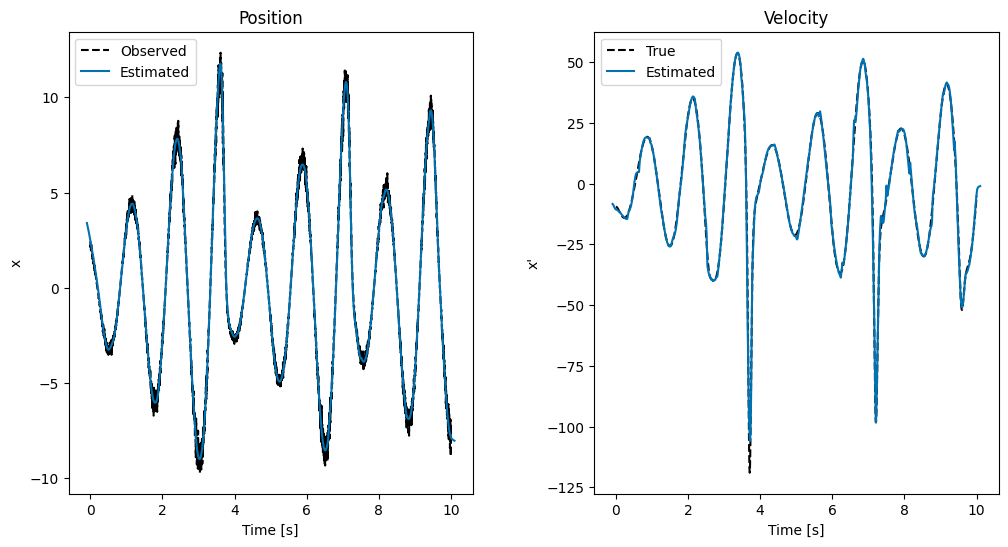

In [16]:
true_velocity = data["x_prime"][: B * T].view(B, T, 1)

plot_trajectories(
    eval_times = output.evaluation_times,
    obs_times=obs_times,
    pred_x=output.reconstructed_values, 
    obs_x=obs_values_noisy,
    pred_v=output.vector_field_mean, 
    obs_v=true_velocity
)

Next we will see how to use the $\texttt{FIM}$ model to solve temporal missing patterns!